    # Notebook de Correção e Interpolação Populacional

### Este script realiza a correção das estimativas populacionais do DATASUS utilizando os dados dos Censos 2010 e 2022 como pontos de referência.

Fluxo de processamento:
1. Carrega dados do DATASUS e Censos
2. Aplica correção baseada nos pontos de ancoragem do Censo
3. Gera visualizações para validação
4. Interpola os dados para frequência mensal
5. Salva o resultado final



In [1]:
from src.pre_process.load_data import load_datasus, load_censo_2010_2012, load_censo_2022, diagnostico_csv, load_ibge
from src.pre_process.preprocess_pop import (
    aplicar_correcao,
    gerar_grafico_erro,
    grafico_populacao_municipio,
    preparar_base_anual,
    gerar_populacao_geom_censos,
    grafico_populacao_geom,
    construir_populacao_corrigida
)

diagnostico_csv('../data/raw/populacao_datasus.csv', sep=';', encoding='utf-8')
diagnostico_csv('../data/raw/dados_censo_2010_a_2012.csv', sep=';', encoding='latin1')
diagnostico_csv('../data/raw/dados_censo_2022.csv', encoding='utf-8')
diagnostico_csv('../data/raw/dados_tse.csv', encoding='utf-8')


censo_2022 = load_censo_2022('../data/raw/dados_censo_2022.csv')
datasus = load_datasus('../data/raw/populacao_datasus.csv', censo_2022)
censo_2010_2012 = load_censo_2010_2012('../data/raw/dados_censo_2010_a_2012.csv', censo_2022)
censo_2010 = censo_2010_2012.copy()
pop_ibge =  load_ibge('../data/raw/dataset_etimativa_pop_ibge_2010_2023.csv')


---- Diagnóstico do arquivo: ../data/raw/populacao_datasus.csv ----
Tipos detectados:
Municipio    object
2010          int64
2011          int64
2012          int64
2013          int64
2014          int64
2015          int64
2016          int64
2017          int64
2018          int64
2019          int64
2020          int64
2021          int64
2022          int64
2023          int64
dtype: object

Amostra de dados:
                      Municipio   2010   2011   2012    2013    2014    2015  \
0  110001 ALTA FLORESTA D'OESTE  24422  24228  24069   25728   25652   25578   
1              110002 ARIQUEMES  90354  91570  92747  101269  102860  104401   
2                 110003 CABIXI   6309   6221   6132    6495    6424    6355   
3                 110004 CACOAL  78601  78959  79330   85863   86556   87226   
4             110005 CEREJEIRAS  17030  16939  16852   18041   18013   17986   

     2016    2017    2018    2019    2020    2021   2022   2023  
0   25506   25437   23167   22945

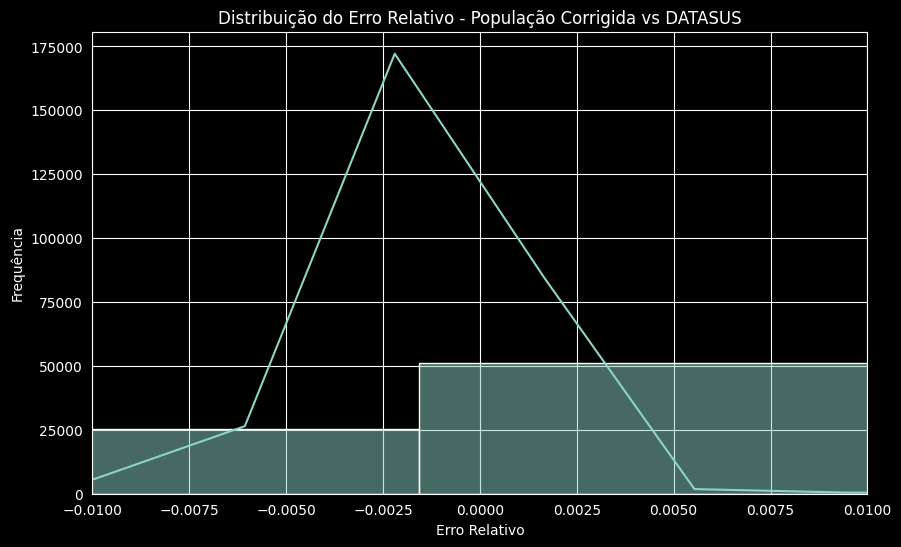

/home/gustavo/Área de Trabalho/tcc-migracao-e-inflacao/src/pre_process/preprocess_pop.py:28: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


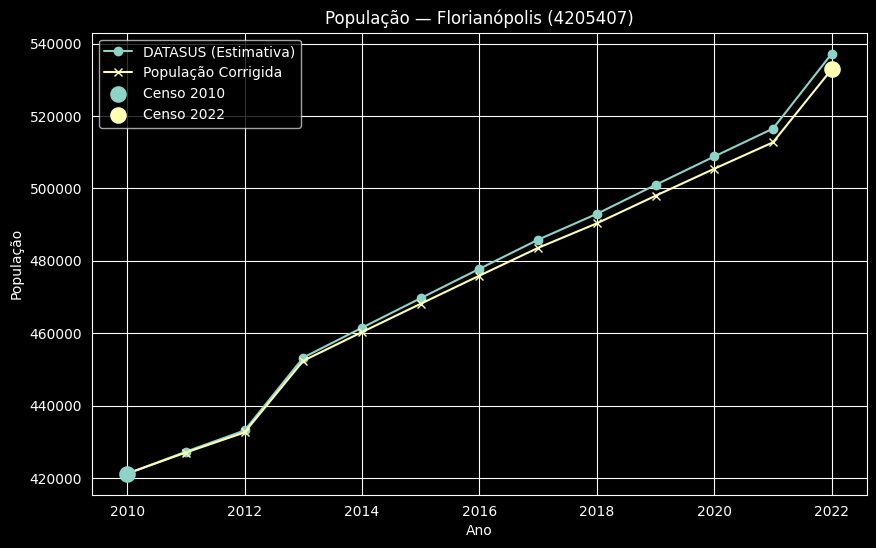

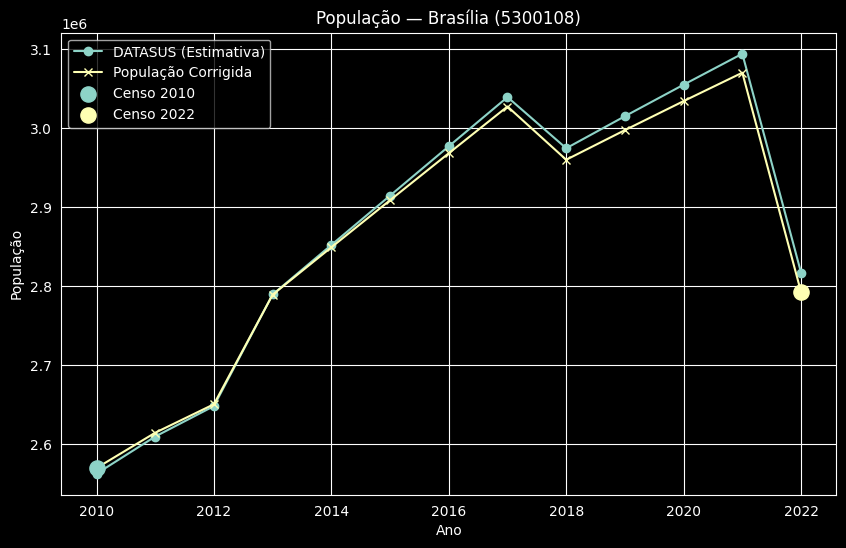

In [2]:
pop_corrigida = aplicar_correcao(datasus, censo_2010, censo_2022)

gerar_grafico_erro(
    pop_corrigida, path_save='../figures/graficos_populacao/erro_relativo.png'
)

pop_anual = preparar_base_anual(pop_corrigida)


pop_anual.head()

pop_anual.to_csv(
    '../data/processed/pop_municipal_corrigido_anual.csv',
    index=False
)


grafico_populacao_municipio(
    pop_corrigida,
    codigo_ibge='4205407',  # Florianópolis
    path_save='../figures/graficos_populacao/florianopolis.png'
)


grafico_populacao_municipio(
    pop_corrigida,
    codigo_ibge='5300108',
    path_save='../figures/graficos_populacao/brasilia.png'
)


como podemos ver há muito ruido, as estimativas do datasus muitas vezes são muito erroneas e vão gerar ruido.


---

## 📈 Estimativa Intercensitária por Crescimento Geométrico

Optou-se por substituir completamente a lógica baseada nas estimativas administrativas do DATASUS por um método demograficamente consistente: **crescimento geométrico composto entre os Censos Demográficos de 2010 e 2022**.

A ideia é simples.



<!--
[
g = \left(\frac{Pop_{2022}}{Pop_{2010}}\right)^{\frac{1}{12}} - 1
]

Onde:

* ( Pop_{2010} ) é a população observada no Censo 2010
* ( Pop_{2022} ) é a população observada no Censo 2022
* 12 corresponde ao número de anos intercensitários

Em seguida, a população anual é estimada por:

[
Pop_t = Pop_{2010}(1+g)^{t-2010}
]
-->
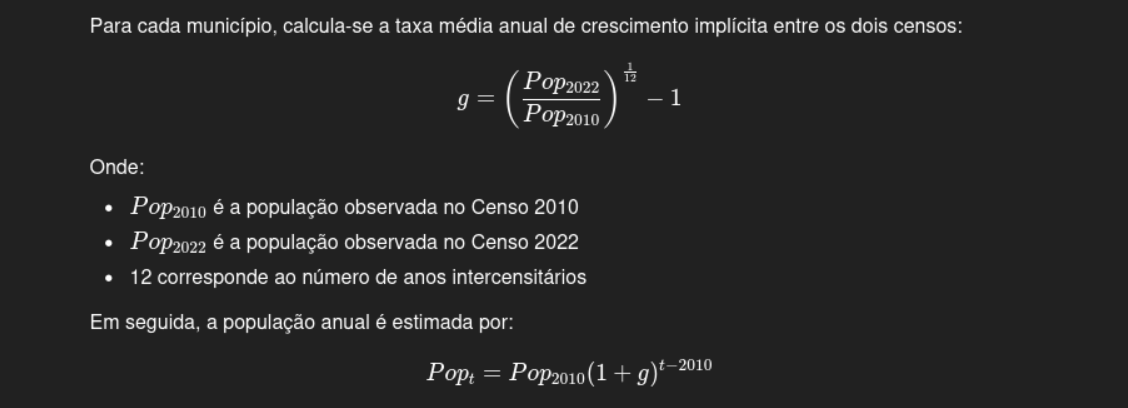
Esse procedimento garante uma trajetória suave, consistente e ancorada exclusivamente em valores observados.

---

## 📚 Justificativa Metodológica

Para estimar a população anual municipal entre os Censos Demográficos de 2010 e 2022, optou-se por um modelo de crescimento geométrico composto, que assume uma taxa de crescimento constante implícita no período intercensitário.

Essa abordagem é coerente com a literatura de estimativas intercensitárias, que busca evitar extrapolações artificiais entre dois pontos de ancoragem observados. O **U.S. Census Bureau** descreve que estimativas intercensitárias são produzidas ajustando séries pós-censitárias para garantir consistência entre censos decenais (U.S. Census Bureau, 2024).
Disponível em:
[https://www.census.gov/programs-surveys/popest/technical-documentation/research/intercensal-estimates.html](https://www.census.gov/programs-surveys/popest/technical-documentation/research/intercensal-estimates.html)

Estudos que avaliam interpolação linear moderna mostram que métodos lineares simples podem introduzir viés quando as tendências demográficas não são estritamente lineares ao longo do tempo. Ver, por exemplo, Weden et al. (2015):
[https://pmc.ncbi.nlm.nih.gov/articles/PMC4624462/](https://pmc.ncbi.nlm.nih.gov/articles/PMC4624462/)

Além disso, métodos geométricos ou exponenciais são amplamente reconhecidos na literatura como modelos plausíveis para projeções populacionais em séries demográficas entre censos, conforme discutido em:
[https://www.mdpi.com/816060](https://www.mdpi.com/816060)

---

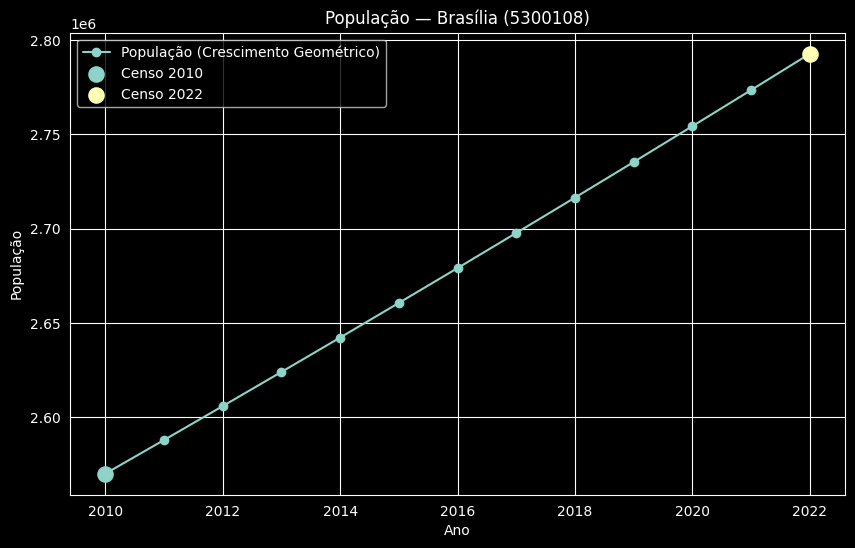

In [3]:
pop_anual = gerar_populacao_geom_censos(
    censo_2010,
    censo_2022
)

pop_anual.to_csv(
    '../data/processed/pop_municipal_geom_2010_2022.csv',
    index=False
)

grafico_populacao_geom(
    df_geom=pop_anual,
    codigo_ibge='5300108',
    path_save='../figures/graficos_populacao_geom/brasilia.png'
)

In [4]:
print(pop_ibge.head())
print(censo_2022.head())
df_pop_corr = construir_populacao_corrigida(
    df_est=pop_ibge,
    df_censo=censo_2022
)

print(df_pop_corr.head())

df_pop_corr.to_csv(
    '../data/processed/pop_municipal_corrigido_anual_ibge.csv',
    index=False
)

   codigo_ibge   ano  populacao
0      1100015  2010      24392
1      1100015  2011      24228
2      1100015  2012      24069
3      1100015  2013      25728
4      1100015  2014      25652
  municipio         nome_municipio   ano  pop_censo_2022 codigo6
0   1100015  Alta Floresta D'Oeste  2022         21440.0  110001
1   1100023              Ariquemes  2022         96152.0  110002
2   1100031                 Cabixi  2022          5351.0  110003
3   1100049                 Cacoal  2022         86494.0  110004
4   1100056             Cerejeiras  2022         15798.0  110005
   codigo_ibge   ano  pop_corrigida  log_pop_corr  dlog_pop_corr
0      1100015  2010   24392.000000     10.102010            NaN
1      1100015  2011   24129.335393     10.091184      -0.010827
2      1100015  2012   23873.364949     10.080519      -0.010665
3      1100015  2013   25414.958936     10.143093       0.062575
4      1100015  2014   25236.691080     10.136054      -0.007039
